<a href="https://colab.research.google.com/github/ACRivera1/data-quality-engine/blob/main/Pricing_Test_Analysis_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pricing Test Analysis - Company XYZ
## Testing $39 vs $59 Price Point

**Goal:** Determine which price generates more revenue and find insights to improve conversion rates.

**Test Setup:**
- Control Group (66%): $39 price
- Test Group (33%): $59 price

---

## STEP 1: IMPORT LIBRARIES

Think of libraries as toolboxes. Each one has specific tools we need:
- **pandas**: For working with data tables (like Excel but in Python)
- **numpy**: For math calculations
- **matplotlib & seaborn**: For creating charts and graphs
- **scipy**: For statistical tests

In [16]:
# Import all the tools we need
import pandas as pd                    # For data manipulation
import numpy as np                     # For numerical operations
import matplotlib.pyplot as plt        # For basic plotting
import seaborn as sns                  # For beautiful statistical plots
from scipy import stats                # For statistical tests
from datetime import datetime          # For working with dates
import warnings
warnings.filterwarnings('ignore')      # Hide warning messages to keep output clean

# Settings to make our output look nice
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 100)      # Show up to 100 rows
plt.style.use('seaborn-v0_8-darkgrid')      # Set plot style
sns.set_palette("husl")                     # Set color palette

# Make plots appear in the notebook
%matplotlib inline

print("✅ All libraries imported successfully!")
print("You're ready to start analyzing!")

✅ All libraries imported successfully!
You're ready to start analyzing!


---
## STEP 2: LOAD THE DATA

Now we'll load our two CSV files into Python.
Think of this like opening two Excel files.

In [17]:
# Load the test results data
# Make sure these CSV files are in the same folder as this notebook!
test_results = pd.read_csv('test_results.csv')
user_table = pd.read_csv('user_table.csv')

print("📊 DATA LOADED SUCCESSFULLY!")
print("="*70)
print(f"\nTest Results: {test_results.shape[0]:,} rows, {test_results.shape[1]} columns")
print(f"User Table: {user_table.shape[0]:,} rows, {user_table.shape[1]} columns")
print("\n✅ Both files loaded correctly!")

📊 DATA LOADED SUCCESSFULLY!

Test Results: 316,800 rows, 8 columns
User Table: 275,616 rows, 5 columns

✅ Both files loaded correctly!


---
## STEP 3: EXPLORE THE DATA

Let's look at what our data looks like.
This is like peeking at the first few rows in Excel.

In [18]:
# Look at first 10 rows of test results
print("=== TEST RESULTS - First 10 Rows ===")
display(test_results.head(10))

=== TEST RESULTS - First 10 Rows ===


,user_id,timestamp,source,device,operative_system,test,price,converted
0,604839,2015-05-08 03:38:34,ads_facebook,mobile,iOS,0,39,0
1,624057,2015-05-10 21:08:46,seo-google,mobile,android,0,39,0
2,317970,2015-04-04 15:01:23,ads-bing,mobile,android,0,39,0
3,685636,2015-05-07 07:26:01,direct_traffic,mobile,iOS,1,59,0
4,820854,2015-05-24 11:04:40,ads_facebook,web,mac,0,39,0
5,169971,2015-04-13 12:07:08,ads-google,mobile,iOS,0,39,0
6,600150,2015-03-04 14:45:44,seo_facebook,web,windows,0,39,0
7,798371,2015-03-15 08:19:29,ads-bing,mobile,android,1,59,1
8,447194,2015-03-28 12:28:10,ads_facebook,web,windows,1,59,0
9,431639,2015-04-24 12:42:18,ads_facebook,web,windows,1,59,0


In [19]:
# Look at first 10 rows of user table
print("=== USER TABLE - First 10 Rows ===")
display(user_table.head(10))

=== USER TABLE - First 10 Rows ===


,user_id,city,country,lat,long
0,510335,Peabody,USA,42.53,-70.97
1,89568,Reno,USA,39.54,-119.82
2,434134,Rialto,USA,34.11,-117.39
3,289769,Carson City,USA,39.15,-119.74
4,939586,Chicago,USA,41.84,-87.68
5,229234,New York,USA,40.67,-73.94
6,339138,Durham,USA,35.98,-78.91
7,270353,New York,USA,40.67,-73.94
8,166748,Burke,USA,38.78,-77.27
9,167700,New York,USA,40.67,-73.94


In [20]:
# Get detailed information about the data types and missing values
print("=== TEST RESULTS - DATA INFO ===")
test_results.info()

print("\n=== USER TABLE - DATA INFO ===")
user_table.info()

=== TEST RESULTS - DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316800 entries, 0 to 316799
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           316800 non-null  int64 
 1   timestamp         316800 non-null  object
 2   source            316800 non-null  object
 3   device            316800 non-null  object
 4   operative_system  316800 non-null  object
 5   test              316800 non-null  int64 
 6   price             316800 non-null  int64 
 7   converted         316800 non-null  int64 
dtypes: int64(4), object(4)
memory usage: 19.3+ MB

=== USER TABLE - DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275616 entries, 0 to 275615
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  275616 non-null  int64  
 1   city     275616 non-null  object 
 2   country  275616 non-null  object 

In [21]:
# Check what columns we have
print("Test Results Columns:")
print(test_results.columns.tolist())

print("\nUser Table Columns:")
print(user_table.columns.tolist())

Test Results Columns:
['user_id', 'timestamp', 'source', 'device', 'operative_system', 'test', 'price', 'converted']

User Table Columns:
['user_id', 'city', 'country', 'lat', 'long']


---
## STEP 4: DATA CLEANING

Before analyzing, we need to make sure the data is clean and ready.
This means checking for:
- Missing values (blank cells)
- Duplicate entries
- Correct data types

In [22]:
# Check for missing values
print("=== MISSING VALUES CHECK ===")
print("\nTest Results:")
print(test_results.isnull().sum())

print("\nUser Table:")
print(user_table.isnull().sum())

# Calculate percentage of missing values
test_missing_pct = (test_results.isnull().sum() / len(test_results) * 100)
user_missing_pct = (user_table.isnull().sum() / len(user_table) * 100)

print("\n=== MISSING VALUES PERCENTAGE ===")
print("\nTest Results:")
print(test_missing_pct[test_missing_pct > 0])

print("\nUser Table:")
print(user_missing_pct[user_missing_pct > 0])

=== MISSING VALUES CHECK ===

Test Results:
user_id             0
timestamp           0
source              0
device              0
operative_system    0
test                0
price               0
converted           0
dtype: int64

User Table:
user_id    0
city       0
country    0
lat        0
long       0
dtype: int64

=== MISSING VALUES PERCENTAGE ===

Test Results:
Series([], dtype: float64)

User Table:
Series([], dtype: float64)


In [23]:
# Check for duplicate user_ids
print("=== DUPLICATE CHECK ===")
test_duplicates = test_results['user_id'].duplicated().sum()
user_duplicates = user_table['user_id'].duplicated().sum()

print(f"Duplicate user_ids in test_results: {test_duplicates}")
print(f"Duplicate user_ids in user_table: {user_duplicates}")

if test_duplicates == 0 and user_duplicates == 0:
    print("\n✅ No duplicates found! Data looks clean.")
else:
    print("\n⚠️ Duplicates found. May need to investigate.")

=== DUPLICATE CHECK ===
Duplicate user_ids in test_results: 0
Duplicate user_ids in user_table: 0

✅ No duplicates found! Data looks clean.


In [24]:
# Convert timestamp to datetime format
# This allows us to work with dates properly
test_results['timestamp'] = pd.to_datetime(test_results['timestamp'], errors='coerce')

print("✅ Timestamp column converted to datetime format")
print(f"\nDate range: {test_results['timestamp'].min()} to {test_results['timestamp'].max()}")
print(f"Test duration: {(test_results['timestamp'].max() - test_results['timestamp'].min()).days} days")

✅ Timestamp column converted to datetime format

Date range: 2015-03-02 00:04:12 to 2015-05-31 23:59:45
Test duration: 90 days


---
## STEP 5: MERGE THE DATASETS

We'll combine both tables so we have all information in one place.
This is like doing a VLOOKUP in Excel.

In [25]:
# Merge the two tables on user_id
# 'left' means keep all rows from test_results, add matching data from user_table
df = test_results.merge(user_table, on='user_id', how='left')

print("✅ Datasets merged successfully!")
print(f"\nCombined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns in merged dataset:")
print(df.columns.tolist())

# Show first few rows
print("\nFirst 5 rows of merged data:")
display(df.head())

✅ Datasets merged successfully!

Combined dataset: 316,800 rows, 12 columns

Columns in merged dataset:
['user_id', 'timestamp', 'source', 'device', 'operative_system', 'test', 'price', 'converted', 'city', 'country', 'lat', 'long']

First 5 rows of merged data:


,user_id,timestamp,source,device,operative_system,test,price,converted,city,country,lat,long
0,604839,2015-05-08 03:38:34,ads_facebook,mobile,iOS,0,39,0,Buffalo,USA,42.89,-78.86
1,624057,2015-05-10 21:08:46,seo-google,mobile,android,0,39,0,Lakeville,USA,44.68,-93.24
2,317970,2015-04-04 15:01:23,ads-bing,mobile,android,0,39,0,Parma,USA,41.38,-81.73
3,685636,2015-05-07 07:26:01,direct_traffic,mobile,iOS,1,59,0,Fayetteville,USA,35.07,-78.90
4,820854,2015-05-24 11:04:40,ads_facebook,web,mac,0,39,0,Fishers,USA,39.95,-86.02


---
## STEP 6: BASIC STATISTICS

Let's get some basic numbers to understand our experiment.

In [26]:
# Overall test statistics
print("="*70)
print("OVERALL TEST STATISTICS")
print("="*70)

total_users = len(df)
control_users = len(df[df['test'] == 0])
test_users = len(df[df['test'] == 1])

print(f"\nTotal users in experiment: {total_users:,}")
print(f"\nControl group ($39): {control_users:,} users ({control_users/total_users*100:.1f}%)")
print(f"Test group ($59): {test_users:,} users ({test_users/total_users*100:.1f}%)")

# Check if split is close to 66/33
expected_control_pct = 66
expected_test_pct = 33
actual_control_pct = control_users/total_users*100
actual_test_pct = test_users/total_users*100

print(f"\n📊 Expected split: {expected_control_pct}% control, {expected_test_pct}% test")
print(f"📊 Actual split: {actual_control_pct:.1f}% control, {actual_test_pct:.1f}% test")

if abs(actual_control_pct - expected_control_pct) < 5:
    print("✅ Split looks good!")
else:
    print("⚠️ Split differs from expected - may need to investigate")

OVERALL TEST STATISTICS

Total users in experiment: 316,800

Control group ($39): 202,727 users (64.0%)
Test group ($59): 114,073 users (36.0%)

📊 Expected split: 66% control, 33% test
📊 Actual split: 64.0% control, 36.0% test
✅ Split looks good!


In [27]:
# Conversion statistics by group
print("="*70)
print("CONVERSION STATISTICS")
print("="*70)

# Overall conversion rate
overall_conversion = df['converted'].mean() * 100
print(f"\nOverall conversion rate: {overall_conversion:.2f}%")

# By price group
control_conversion = df[df['test'] == 0]['converted'].mean() * 100
test_conversion = df[df['test'] == 1]['converted'].mean() * 100

print(f"\nControl group ($39) conversion rate: {control_conversion:.2f}%")
print(f"Test group ($59) conversion rate: {test_conversion:.2f}%")

# Difference
conversion_diff = test_conversion - control_conversion
print(f"\nDifference: {conversion_diff:+.2f} percentage points")

if conversion_diff > 0:
    print("📈 Test group has HIGHER conversion rate")
else:
    print("📉 Test group has LOWER conversion rate")

CONVERSION STATISTICS

Overall conversion rate: 1.83%

Control group ($39) conversion rate: 1.99%
Test group ($59) conversion rate: 1.55%

Difference: -0.44 percentage points
📉 Test group has LOWER conversion rate


In [28]:
# Revenue analysis - THE MOST IMPORTANT METRIC!
print("="*70)
print("REVENUE ANALYSIS")
print("="*70)

# Calculate revenue for each group
# Revenue = Number of conversions × Price
control_conversions = df[df['test'] == 0]['converted'].sum()
test_conversions = df[df['test'] == 1]['converted'].sum()

control_revenue = control_conversions * 39
test_revenue = test_conversions * 59

print(f"\nControl group ($39):")
print(f"  Conversions: {control_conversions:,}")
print(f"  Revenue: ${control_revenue:,.2f}")

print(f"\nTest group ($59):")
print(f"  Conversions: {test_conversions:,}")
print(f"  Revenue: ${test_revenue:,.2f}")

# Total revenue
total_revenue = control_revenue + test_revenue
print(f"\nTotal revenue from experiment: ${total_revenue:,.2f}")

# Revenue per user (more fair comparison)
control_rev_per_user = control_revenue / control_users
test_rev_per_user = test_revenue / test_users

print(f"\n💰 REVENUE PER USER (Key Metric):")
print(f"Control group ($39): ${control_rev_per_user:.2f} per user")
print(f"Test group ($59): ${test_rev_per_user:.2f} per user")

revenue_diff = test_rev_per_user - control_rev_per_user
revenue_diff_pct = (revenue_diff / control_rev_per_user) * 100

print(f"\nDifference: ${revenue_diff:+.2f} per user ({revenue_diff_pct:+.1f}%)")

if revenue_diff > 0:
    print(f"\n🎉 Test group generates ${revenue_diff:.2f} MORE per user!")
    print("✅ RECOMMENDATION: Consider adopting $59 price")
else:
    print(f"\n⚠️ Test group generates ${abs(revenue_diff):.2f} LESS per user!")
    print("✅ RECOMMENDATION: Keep $39 price")

REVENUE ANALYSIS

Control group ($39):
  Conversions: 4,035
  Revenue: $157,365.00

Test group ($59):
  Conversions: 1,773
  Revenue: $104,607.00

Total revenue from experiment: $261,972.00

💰 REVENUE PER USER (Key Metric):
Control group ($39): $0.78 per user
Test group ($59): $0.92 per user

Difference: $+0.14 per user (+18.1%)

🎉 Test group generates $0.14 MORE per user!
✅ RECOMMENDATION: Consider adopting $59 price


---
## STEP 7: STATISTICAL SIGNIFICANCE TEST

We need to check if the difference between groups is real or just random luck.
This is called a "statistical significance test".

We'll use a **Chi-Square test** for conversion rates.

In [29]:
# Create a contingency table
# This shows how many people converted vs didn't convert in each group
contingency_table = pd.crosstab(df['test'], df['converted'])

print("=== CONVERSION CONTINGENCY TABLE ===")
print("\nRows: Test group (0 = Control $39, 1 = Test $59)")
print("Columns: Converted (0 = No, 1 = Yes)\n")
display(contingency_table)

# Perform Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\n=== CHI-SQUARE TEST RESULTS ===")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Interpret the p-value
alpha = 0.05  # Standard significance level
print(f"\nSignificance level (alpha): {alpha}")

if p_value < alpha:
    print(f"\n✅ STATISTICALLY SIGNIFICANT (p-value {p_value:.4f} < {alpha})")
    print("The difference in conversion rates is NOT due to random chance.")
    print("We can be confident that the price change has a real effect.")
else:
    print(f"\n⚠️ NOT STATISTICALLY SIGNIFICANT (p-value {p_value:.4f} >= {alpha})")
    print("The difference might be due to random chance.")
    print("We need more data or the difference is too small to matter.")

=== CONVERSION CONTINGENCY TABLE ===

Rows: Test group (0 = Control $39, 1 = Test $59)
Columns: Converted (0 = No, 1 = Yes)



converted,0,1
test,,
0,198692,4035
1,112300,1773



=== CHI-SQUARE TEST RESULTS ===
Chi-square statistic: 76.8949
P-value: 0.0000
Degrees of freedom: 1

Significance level (alpha): 0.05

✅ STATISTICALLY SIGNIFICANT (p-value 0.0000 < 0.05)
The difference in conversion rates is NOT due to random chance.
We can be confident that the price change has a real effect.


---
## STEP 8: VISUALIZATIONS

Charts make it easy to see patterns in the data.

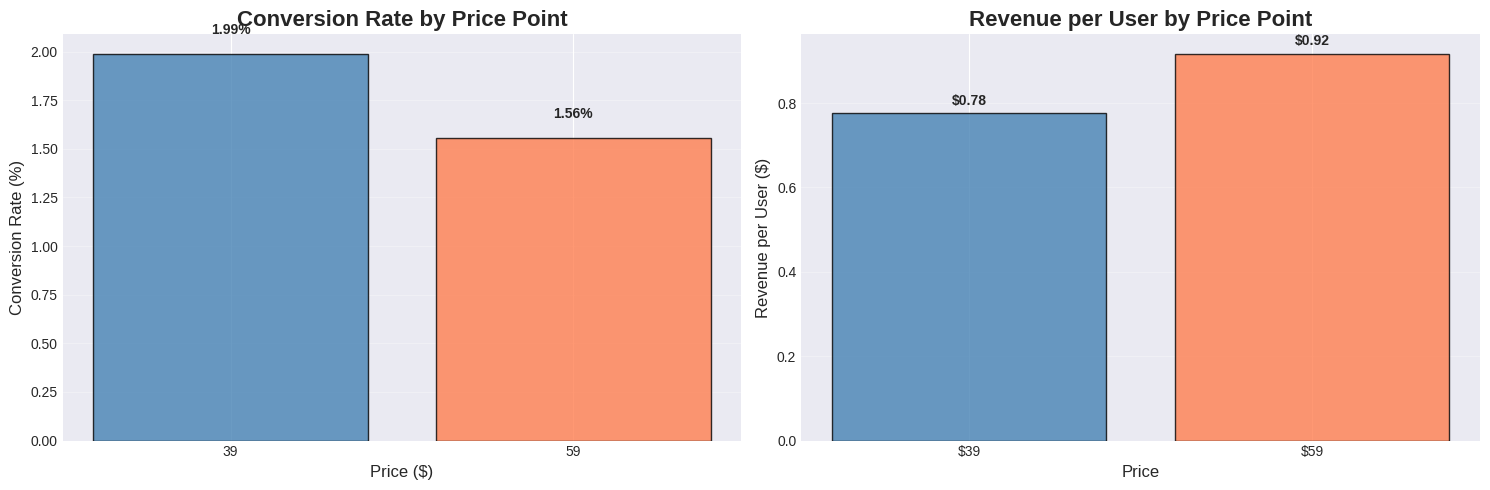


📊 Charts created successfully!


In [30]:
# Visualization 1: Conversion Rate by Price
conversion_by_price = df.groupby('price')['converted'].agg(['mean', 'count']).reset_index()
conversion_by_price['conversion_rate'] = conversion_by_price['mean'] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart of conversion rates
colors = ['steelblue', 'coral']
axes[0].bar(conversion_by_price['price'].astype(str),
            conversion_by_price['conversion_rate'],
            color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Conversion Rate by Price Point', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, v in enumerate(conversion_by_price['conversion_rate']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Revenue per user comparison
rev_comparison = pd.DataFrame({
    'Price': ['$39', '$59'],
    'Revenue per User': [control_rev_per_user, test_rev_per_user]
})

axes[1].bar(rev_comparison['Price'], rev_comparison['Revenue per User'],
            color=colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Revenue per User by Price Point', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Price', fontsize=12)
axes[1].set_ylabel('Revenue per User ($)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(rev_comparison['Revenue per User']):
    axes[1].text(i, v + 0.02, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Charts created successfully!")

---
## STEP 9: SEGMENT ANALYSIS

Now let's break down the results by different user segments:
- Traffic source (where users came from)
- Device type (mobile vs web)
- Operating system
- Country

ANALYSIS BY TRAFFIC SOURCE


,source,price,conversions,users,conversion_rate,revenue_per_user
0,ads-bing,39,195,14601,1.335525,0.520855
1,ads-bing,59,79,8272,0.955029,0.563467
2,ads-google,39,854,37863,2.255500,0.879645
3,ads-google,59,422,21516,1.961331,1.157185
4,ads-yahoo,39,81,4818,1.681196,0.655666
5,ads-yahoo,59,31,2765,1.121157,0.661483
6,ads_facebook,39,806,34090,2.364330,0.922089
7,ads_facebook,59,326,19306,1.688594,0.996271
8,ads_other,39,298,19278,1.545804,0.602863
9,ads_other,59,131,10598,1.236082,0.729289


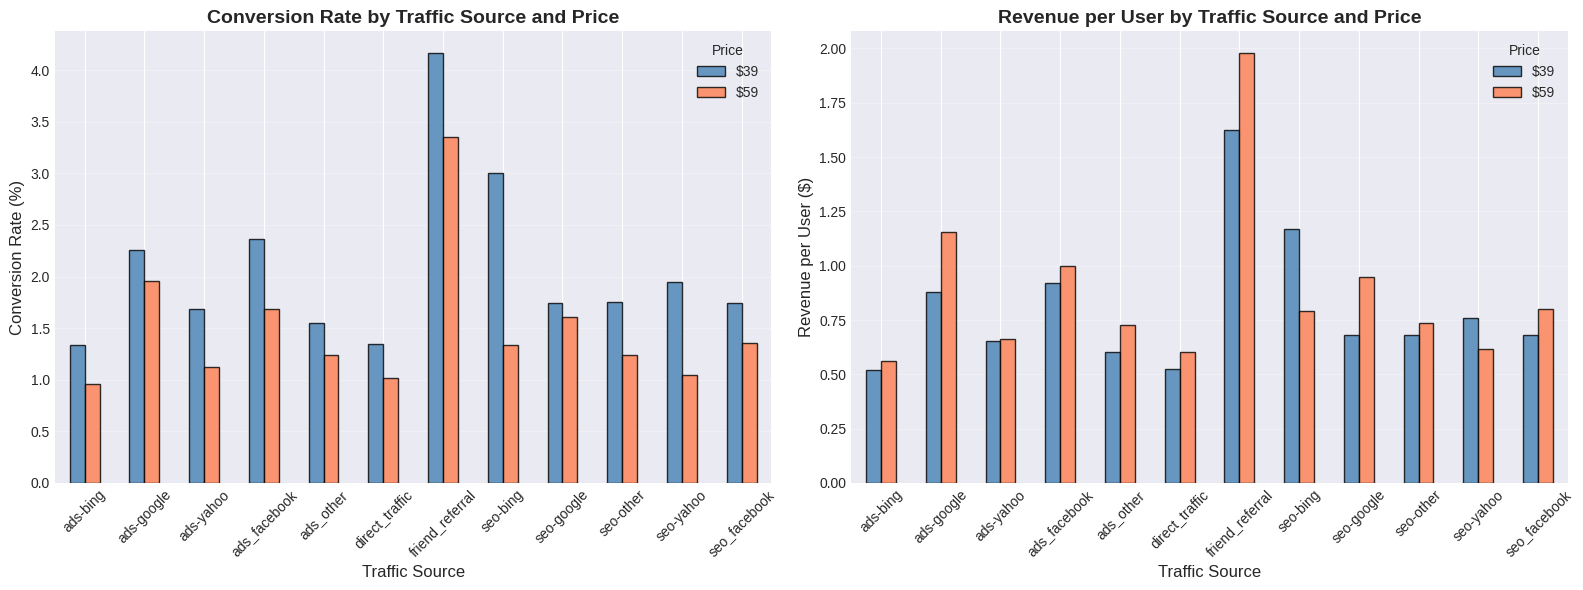

In [31]:
# Analysis by Traffic Source
print("="*70)
print("ANALYSIS BY TRAFFIC SOURCE")
print("="*70)

source_analysis = df.groupby(['source', 'price'])['converted'].agg(['sum', 'count', 'mean']).reset_index()
source_analysis.columns = ['source', 'price', 'conversions', 'users', 'conversion_rate']
source_analysis['conversion_rate'] = source_analysis['conversion_rate'] * 100

# Calculate revenue per user for each source and price
source_analysis['revenue_per_user'] = source_analysis['conversions'] * source_analysis['price'] / source_analysis['users']

display(source_analysis)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Conversion rate by source
pivot_conv = source_analysis.pivot(index='source', columns='price', values='conversion_rate')
pivot_conv.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[0].set_title('Conversion Rate by Traffic Source and Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Traffic Source', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].legend(title='Price', labels=['$39', '$59'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Revenue per user by source
pivot_rev = source_analysis.pivot(index='source', columns='price', values='revenue_per_user')
pivot_rev.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[1].set_title('Revenue per User by Traffic Source and Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Traffic Source', fontsize=12)
axes[1].set_ylabel('Revenue per User ($)', fontsize=12)
axes[1].legend(title='Price', labels=['$39', '$59'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

ANALYSIS BY DEVICE TYPE


,device,price,conversions,users,conversion_rate,revenue_per_user
0,mobile,39,2393,120461,1.986535,0.774749
1,mobile,59,1067,66010,1.616422,0.953689
2,web,39,1638,82211,1.992434,0.777049
3,web,59,710,48118,1.475539,0.870568


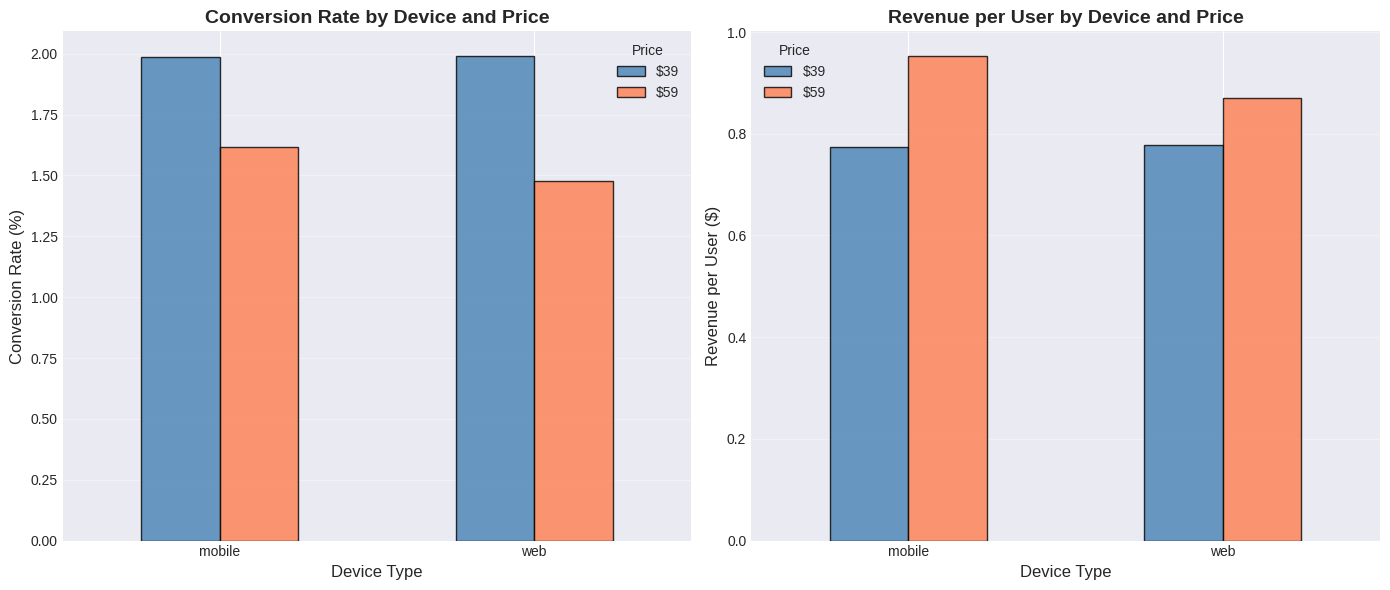

In [32]:
# Analysis by Device Type
print("="*70)
print("ANALYSIS BY DEVICE TYPE")
print("="*70)

device_analysis = df.groupby(['device', 'price'])['converted'].agg(['sum', 'count', 'mean']).reset_index()
device_analysis.columns = ['device', 'price', 'conversions', 'users', 'conversion_rate']
device_analysis['conversion_rate'] = device_analysis['conversion_rate'] * 100
device_analysis['revenue_per_user'] = device_analysis['conversions'] * device_analysis['price'] / device_analysis['users']

display(device_analysis)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pivot_conv = device_analysis.pivot(index='device', columns='price', values='conversion_rate')
pivot_conv.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[0].set_title('Conversion Rate by Device and Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Device Type', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].legend(title='Price', labels=['$39', '$59'])
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

pivot_rev = device_analysis.pivot(index='device', columns='price', values='revenue_per_user')
pivot_rev.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[1].set_title('Revenue per User by Device and Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Device Type', fontsize=12)
axes[1].set_ylabel('Revenue per User ($)', fontsize=12)
axes[1].legend(title='Price', labels=['$39', '$59'])
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

ANALYSIS BY OPERATING SYSTEM


,operative_system,price,conversions,users,conversion_rate,revenue_per_user
10,windows,39,1188,63569,1.868835,0.728846
2,iOS,39,1459,61843,2.359200,0.920088
0,android,39,787,48209,1.632475,0.636665
11,windows,59,524,37407,1.400807,0.826476
3,iOS,59,672,33622,1.998691,1.179228
1,android,59,332,26726,1.242236,0.732919
6,mac,39,416,16354,2.543720,0.992051
8,other,39,147,10491,1.401201,0.546468
7,mac,59,186,8731,2.130340,1.256901
9,other,59,63,5713,1.102748,0.650621


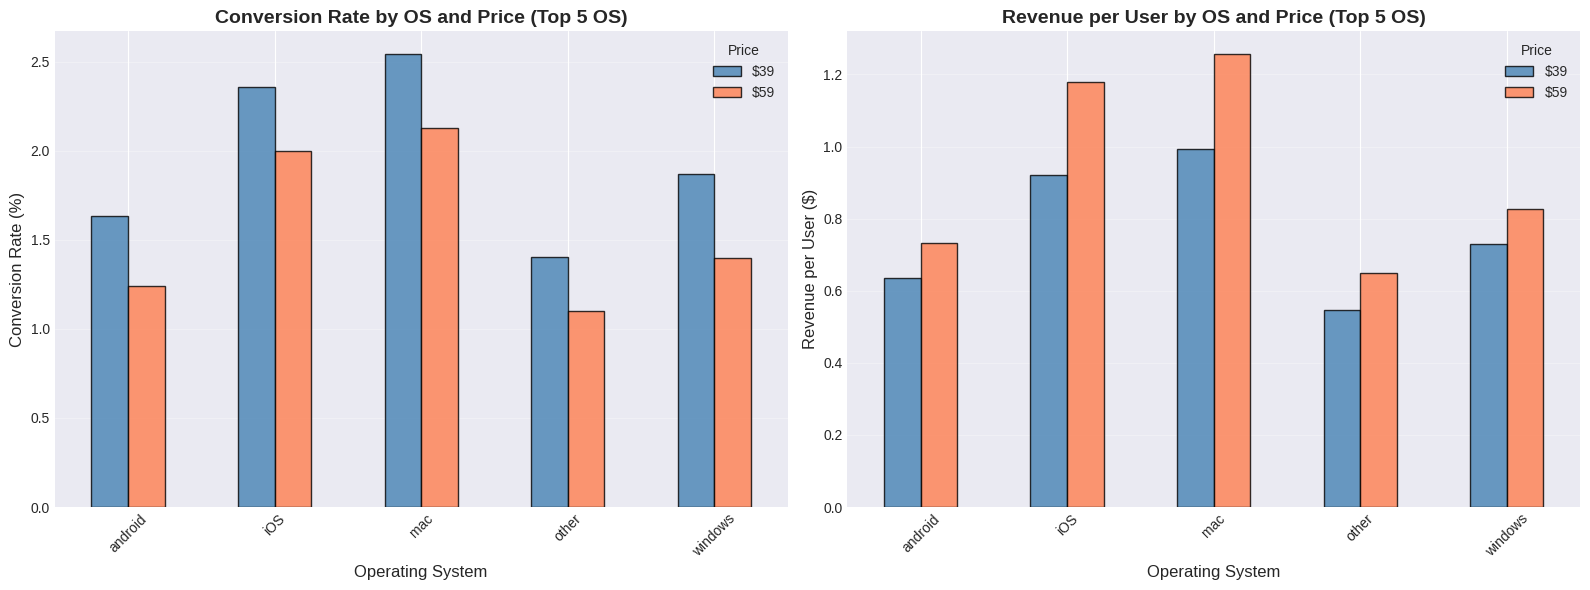

In [33]:
# Analysis by Operating System
print("="*70)
print("ANALYSIS BY OPERATING SYSTEM")
print("="*70)

os_analysis = df.groupby(['operative_system', 'price'])['converted'].agg(['sum', 'count', 'mean']).reset_index()
os_analysis.columns = ['operative_system', 'price', 'conversions', 'users', 'conversion_rate']
os_analysis['conversion_rate'] = os_analysis['conversion_rate'] * 100
os_analysis['revenue_per_user'] = os_analysis['conversions'] * os_analysis['price'] / os_analysis['users']

# Sort by number of users
os_analysis = os_analysis.sort_values('users', ascending=False)

display(os_analysis)

# Visualize top operating systems
top_os = os_analysis.groupby('operative_system')['users'].sum().nlargest(5).index
os_subset = os_analysis[os_analysis['operative_system'].isin(top_os)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_conv = os_subset.pivot(index='operative_system', columns='price', values='conversion_rate')
pivot_conv.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[0].set_title('Conversion Rate by OS and Price (Top 5 OS)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Operating System', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].legend(title='Price', labels=['$39', '$59'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

pivot_rev = os_subset.pivot(index='operative_system', columns='price', values='revenue_per_user')
pivot_rev.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[1].set_title('Revenue per User by OS and Price (Top 5 OS)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Operating System', fontsize=12)
axes[1].set_ylabel('Revenue per User ($)', fontsize=12)
axes[1].legend(title='Price', labels=['$39', '$59'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

ANALYSIS BY COUNTRY (Top 10)


,country,price,conversions,users,conversion_rate,revenue_per_user
0,USA,39,3484,176376,1.975325,0.770377
1,USA,59,1535,99240,1.546755,0.912586


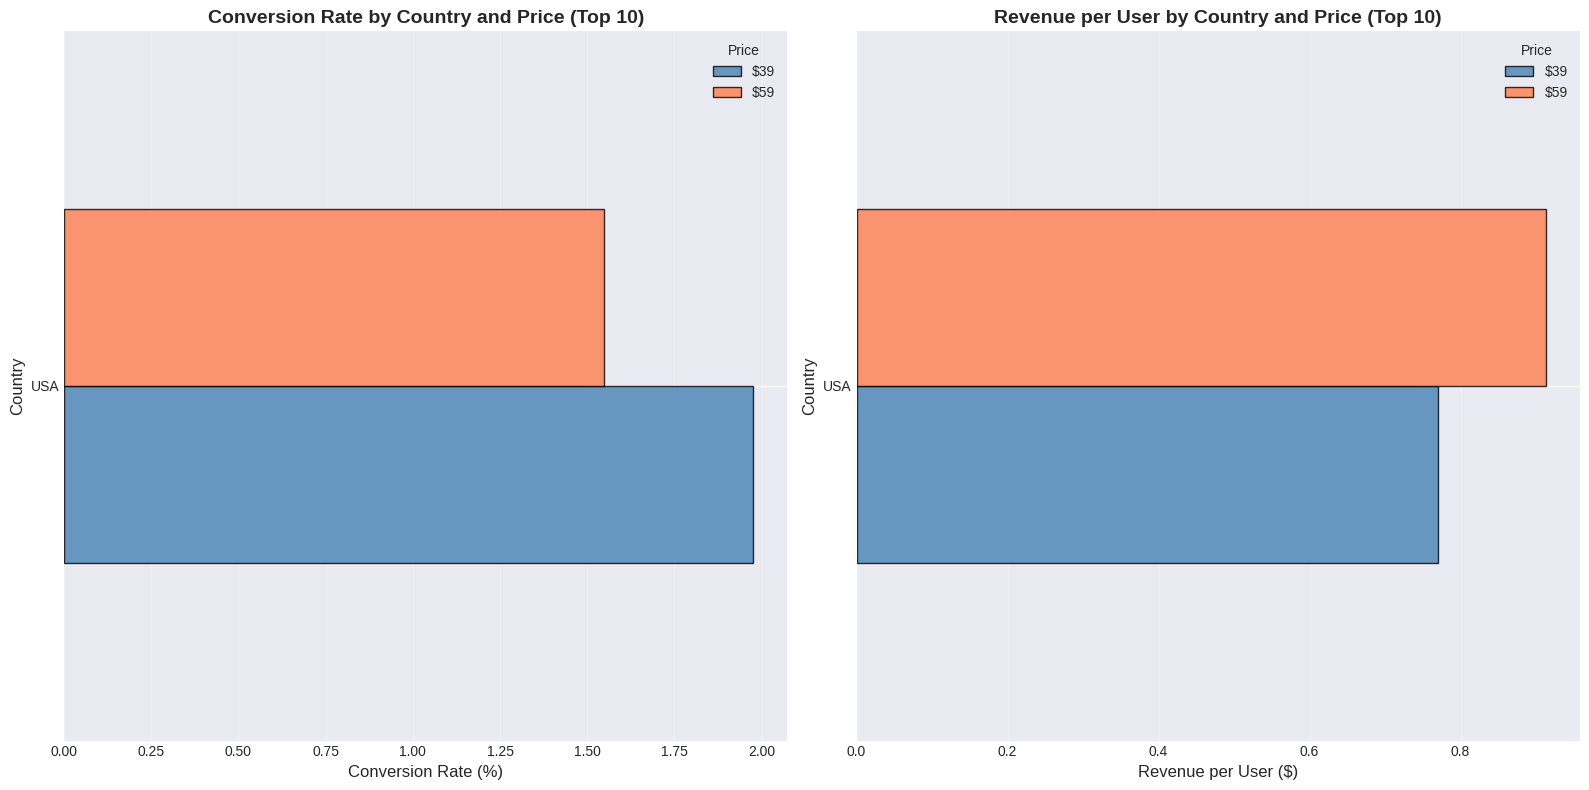

In [34]:
# Analysis by Country (Top 10 countries)
print("="*70)
print("ANALYSIS BY COUNTRY (Top 10)")
print("="*70)

country_analysis = df.groupby(['country', 'price'])['converted'].agg(['sum', 'count', 'mean']).reset_index()
country_analysis.columns = ['country', 'price', 'conversions', 'users', 'conversion_rate']
country_analysis['conversion_rate'] = country_analysis['conversion_rate'] * 100
country_analysis['revenue_per_user'] = country_analysis['conversions'] * country_analysis['price'] / country_analysis['users']

# Get top 10 countries by total users
top_countries = df['country'].value_counts().head(10).index
country_subset = country_analysis[country_analysis['country'].isin(top_countries)]

display(country_subset.sort_values('users', ascending=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

pivot_conv = country_subset.pivot(index='country', columns='price', values='conversion_rate')
pivot_conv.plot(kind='barh', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[0].set_title('Conversion Rate by Country and Price (Top 10)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Conversion Rate (%)', fontsize=12)
axes[0].set_ylabel('Country', fontsize=12)
axes[0].legend(title='Price', labels=['$39', '$59'])
axes[0].grid(True, alpha=0.3, axis='x')

pivot_rev = country_subset.pivot(index='country', columns='price', values='revenue_per_user')
pivot_rev.plot(kind='barh', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black', alpha=0.8)
axes[1].set_title('Revenue per User by Country and Price (Top 10)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue per User ($)', fontsize=12)
axes[1].set_ylabel('Country', fontsize=12)
axes[1].legend(title='Price', labels=['$39', '$59'])
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## STEP 10: TIME ANALYSIS

Let's see how conversion rates changed over time during the test.

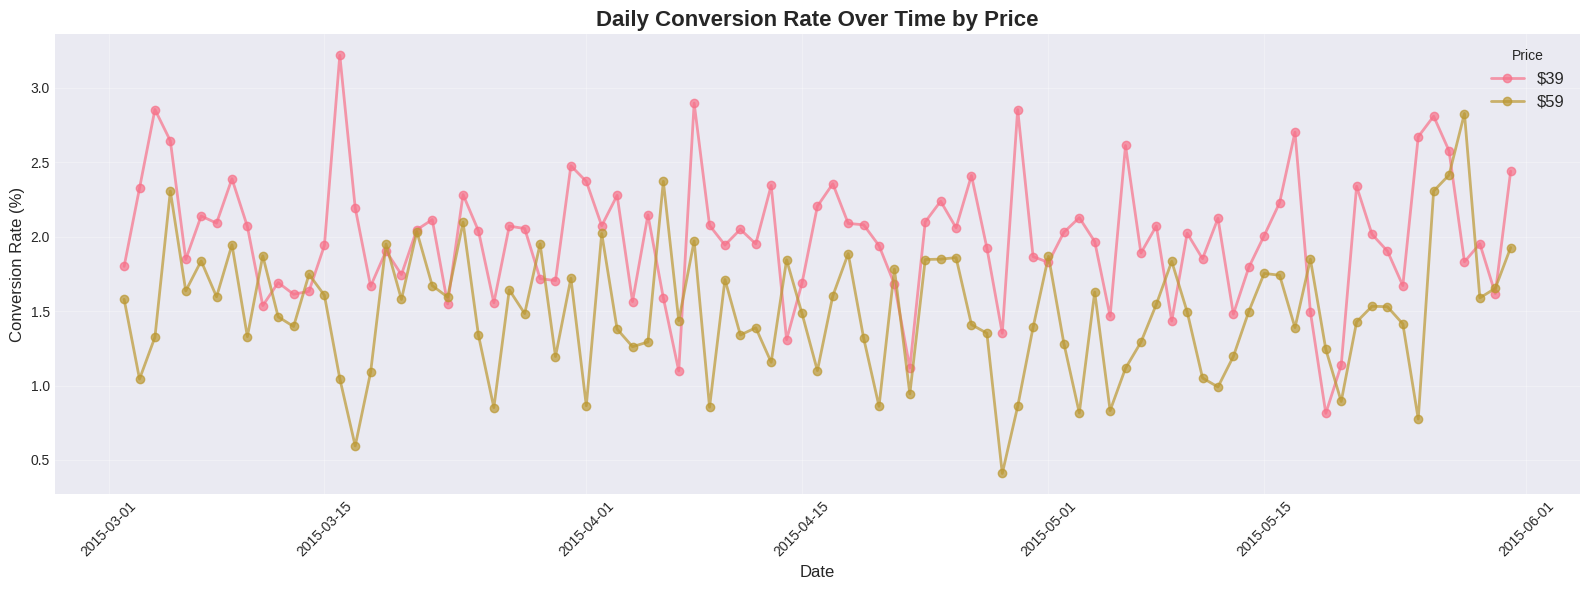


📅 Time series shows how conversion rates fluctuated during the test


In [35]:
# Add date column (without time)
df['date'] = df['timestamp'].dt.date

# Daily conversion rates by price
daily_conv = df.groupby(['date', 'price'])['converted'].agg(['sum', 'count', 'mean']).reset_index()
daily_conv.columns = ['date', 'price', 'conversions', 'users', 'conversion_rate']
daily_conv['conversion_rate'] = daily_conv['conversion_rate'] * 100

# Plot
plt.figure(figsize=(16, 6))

for price in [39, 59]:
    data = daily_conv[daily_conv['price'] == price]
    plt.plot(data['date'], data['conversion_rate'],
             marker='o', label=f'${price}', linewidth=2, alpha=0.7)

plt.title('Daily Conversion Rate Over Time by Price', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.legend(fontsize=12, title='Price')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📅 Time series shows how conversion rates fluctuated during the test")

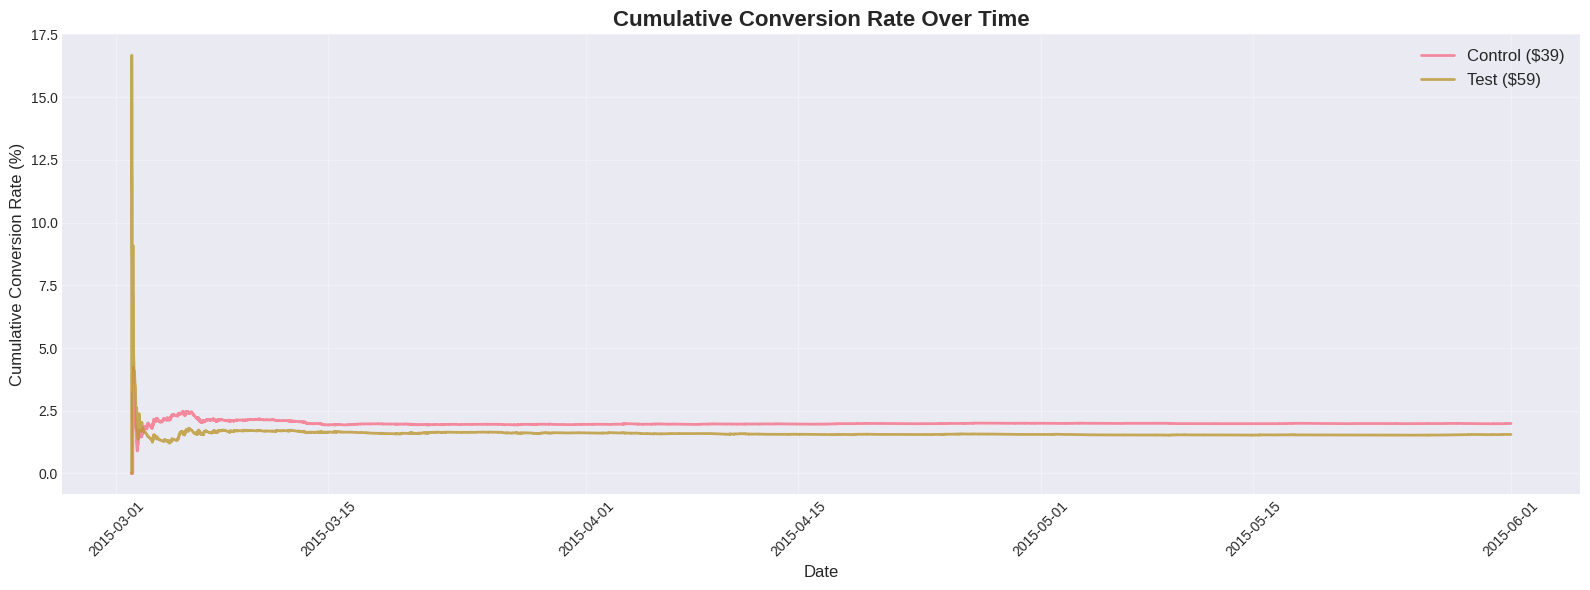


📊 If lines stabilize (become flat), the test has run long enough
If lines are still changing significantly, need more time


In [36]:
# Calculate cumulative conversion rate over time
# This shows if the test stabilized

df_sorted = df.sort_values('timestamp')

# Separate by test group
control_data = df_sorted[df_sorted['test'] == 0].copy()
test_data = df_sorted[df_sorted['test'] == 1].copy()

# Calculate cumulative conversion rate
control_data['cumulative_conv_rate'] = control_data['converted'].expanding().mean() * 100
test_data['cumulative_conv_rate'] = test_data['converted'].expanding().mean() * 100

# Plot
plt.figure(figsize=(16, 6))
plt.plot(control_data['timestamp'], control_data['cumulative_conv_rate'],
         label='Control ($39)', linewidth=2, alpha=0.8)
plt.plot(test_data['timestamp'], test_data['cumulative_conv_rate'],
         label='Test ($59)', linewidth=2, alpha=0.8)

plt.title('Cumulative Conversion Rate Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Conversion Rate (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 If lines stabilize (become flat), the test has run long enough")
print("If lines are still changing significantly, need more time")

---
## STEP 11: FINAL RECOMMENDATIONS

Let's summarize everything and provide clear recommendations.

In [37]:
print("="*80)
print("FINAL ANALYSIS SUMMARY & RECOMMENDATIONS")
print("="*80)

print("\n📊 1. WHICH PRICE SHOULD THE COMPANY ADOPT?")
print("="*80)

print(f"\nControl Group ($39):")
print(f"  • Conversion Rate: {control_conversion:.2f}%")
print(f"  • Revenue per User: ${control_rev_per_user:.2f}")

print(f"\nTest Group ($59):")
print(f"  • Conversion Rate: {test_conversion:.2f}%")
print(f"  • Revenue per User: ${test_rev_per_user:.2f}")

print(f"\nKey Metrics:")
print(f"  • Conversion Rate Difference: {conversion_diff:+.2f} percentage points")
print(f"  • Revenue per User Difference: ${revenue_diff:+.2f} ({revenue_diff_pct:+.1f}%)")
print(f"  • Statistical Significance: {'YES' if p_value < 0.05 else 'NO'} (p-value: {p_value:.4f})")

if revenue_diff > 0 and p_value < 0.05:
    print(f"\n✅ RECOMMENDATION: ADOPT $59 PRICE")
    print(f"   The $59 price generates ${revenue_diff:.2f} more per user ({revenue_diff_pct:+.1f}%)")
    print(f"   This difference is statistically significant.")
    projected_annual_increase = revenue_diff * total_users * 12  # Assuming this is monthly data
    print(f"   Projected annual revenue increase: ~${projected_annual_increase:,.0f}")
elif revenue_diff < 0:
    print(f"\n✅ RECOMMENDATION: KEEP $39 PRICE")
    print(f"   The $39 price generates ${abs(revenue_diff):.2f} more per user")
    print(f"   The higher price reduces revenue.")
else:
    print(f"\n⚠️ RECOMMENDATION: NEED MORE DATA")
    print(f"   The difference is not statistically significant.")
    print(f"   Continue the test or the prices perform similarly.")

print("\n\n💡 2. ACTIONABLE INSIGHTS TO INCREASE CONVERSION RATE")
print("="*80)

# Find best performing segments
print("\n📍 High-Converting Segments (Focus Here):")

# Best traffic source
best_source = source_analysis.groupby('source')['conversion_rate'].mean().idxmax()
best_source_conv = source_analysis.groupby('source')['conversion_rate'].mean().max()
print(f"  • Best traffic source: {best_source} ({best_source_conv:.2f}% avg conversion)")
print(f"    ACTION: Increase marketing budget for {best_source}")

# Best device
best_device = device_analysis.groupby('device')['conversion_rate'].mean().idxmax()
best_device_conv = device_analysis.groupby('device')['conversion_rate'].mean().max()
print(f"\n  • Best device: {best_device} ({best_device_conv:.2f}% avg conversion)")
print(f"    ACTION: Optimize user experience for {best_device} users")

# Best OS
best_os = os_analysis.groupby('operative_system')['conversion_rate'].mean().idxmax()
best_os_conv = os_analysis.groupby('operative_system')['conversion_rate'].mean().max()
print(f"\n  • Best OS: {best_os} ({best_os_conv:.2f}% avg conversion)")
print(f"    ACTION: Ensure software works perfectly on {best_os}")

print("\n\n📉 Low-Converting Segments (Improve Here):")

# Worst traffic source
worst_source = source_analysis.groupby('source')['conversion_rate'].mean().idxmin()
worst_source_conv = source_analysis.groupby('source')['conversion_rate'].mean().min()
print(f"  • Worst traffic source: {worst_source} ({worst_source_conv:.2f}% avg conversion)")
print(f"    ACTION: Improve targeting or reduce spending on {worst_source}")

# Worst device
worst_device = device_analysis.groupby('device')['conversion_rate'].mean().idxmin()
worst_device_conv = device_analysis.groupby('device')['conversion_rate'].mean().min()
print(f"\n  • Worst device: {worst_device} ({worst_device_conv:.2f}% avg conversion)")
print(f"    ACTION: Improve UX/UI for {worst_device} users")

print("\n\n⏱️ 3. TEST DURATION ASSESSMENT")
print("="*80)

test_duration = (df['timestamp'].max() - df['timestamp'].min()).days
print(f"\nTest ran for: {test_duration} days")
print(f"Total users tested: {total_users:,}")
print(f"Statistical significance achieved: {'YES' if p_value < 0.05 else 'NO'}")

if p_value < 0.05:
    print(f"\n✅ TEST CAN BE CONCLUDED")
    print(f"   We have statistically significant results.")
    print(f"   Recommendation: Implement the winning price.")
else:
    print(f"\n⚠️ CONTINUE THE TEST")
    print(f"   Results are not yet statistically significant.")
    print(f"   Recommendation: Run for at least 2-4 more weeks.")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)

FINAL ANALYSIS SUMMARY & RECOMMENDATIONS

📊 1. WHICH PRICE SHOULD THE COMPANY ADOPT?

Control Group ($39):
  • Conversion Rate: 1.99%
  • Revenue per User: $0.78

Test Group ($59):
  • Conversion Rate: 1.55%
  • Revenue per User: $0.92

Key Metrics:
  • Conversion Rate Difference: -0.44 percentage points
  • Revenue per User Difference: $+0.14 (+18.1%)
  • Statistical Significance: YES (p-value: 0.0000)

✅ RECOMMENDATION: ADOPT $59 PRICE
   The $59 price generates $0.14 more per user (+18.1%)
   This difference is statistically significant.
   Projected annual revenue increase: ~$535,178


💡 2. ACTIONABLE INSIGHTS TO INCREASE CONVERSION RATE

📍 High-Converting Segments (Focus Here):
  • Best traffic source: friend_referral (3.76% avg conversion)
    ACTION: Increase marketing budget for friend_referral

  • Best device: mobile (1.80% avg conversion)
    ACTION: Optimize user experience for mobile users

  • Best OS: mac (2.34% avg conversion)
    ACTION: Ensure software works perfectly

---
## 📝 NEXT STEPS FOR YOUR REPORT

### What to Include in Your Report:

1. **Executive Summary** (1 page)
   - Which price won and why
   - Expected revenue impact
   - Top 3 recommendations

2. **Test Overview** (1 page)
   - Test setup (66/33 split)
   - Duration and sample size
   - Data sources

3. **Key Findings** (2-3 pages)
   - Overall conversion and revenue metrics
   - Statistical significance results
   - Charts from this analysis

4. **Segment Analysis** (2-3 pages)
   - Performance by traffic source
   - Performance by device
   - Performance by country
   - Include visualizations

5. **Recommendations** (1-2 pages)
   - Pricing decision
   - Marketing optimizations
   - UX improvements
   - Next steps

6. **Appendix** (optional)
   - Detailed statistical tests
   - Additional charts
   - Code snippets

### For Your Presentation:
- 10-12 slides maximum
- Start with the recommendation (answer first!)
- Use the charts from this notebook
- Focus on business impact, not technical details

---

**🎉 Congratulations! You've completed a professional pricing analysis!**